In [9]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [10]:
# Simulated time-series data (e.g., hourly activity + sleep score)
np.random.seed(42)

time_steps = 200

activity = np.sin(np.linspace(0, 200, time_steps)) * 50 + 100
sleep = np.cos(np.linspace(0, 200, time_steps)) * 10 + 70

# Add noise
activity += np.random.normal(0, 5, time_steps)
sleep += np.random.normal(0, 2, time_steps)

# Inject anomalies
activity[50] = 200
activity[120] = 20

df = pd.DataFrame({
    "Activity": activity,
    "Sleep": sleep
})

df.head()

,Activity,Sleep
0,102.483571,80.715575
1,141.517450,76.482239
2,148.491902,67.913459
3,113.924151,62.187531
4,60.339868,60.861656


In [11]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [12]:
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

In [13]:
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(X.shape[1], X.shape[2])),
    Dense(2)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,702 (41.80 KB)

 Trainable params: 10,702 (41.80 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.fit(X, y, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1781
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0780
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0679
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0662
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0647
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0616
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0588
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0577
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0535
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0513
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0471
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0424
Epoch 13/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0367
Epoch 14/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0310
Epoch 15/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0215
Epoch 

In [15]:
predictions = model.predict(X)

# Calculate reconstruction error
error = np.mean(np.abs(predictions - y), axis=1)

# Define anomaly threshold
threshold = np.percentile(error, 95)

anomalies = error > threshold

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


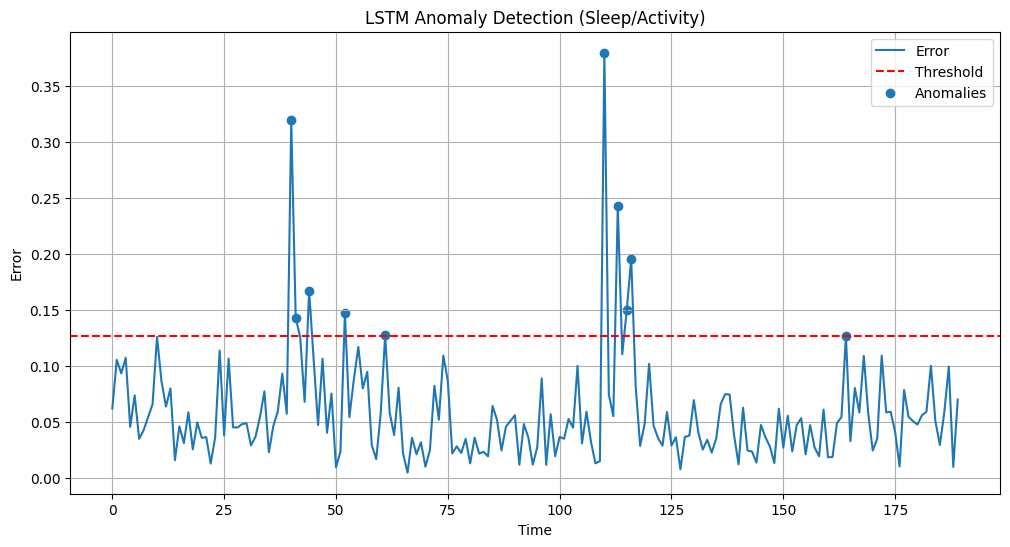

In [16]:
plt.figure(figsize=(12,6))

plt.plot(error, label="Error")
plt.axhline(threshold, color='red', linestyle='--', label="Threshold")

# Mark anomalies
plt.scatter(np.where(anomalies)[0], error[anomalies], label="Anomalies")

plt.title("LSTM Anomaly Detection (Sleep/Activity)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.grid()

plt.show()